# IMPORT LIBRARY

In [12]:
# ==============================
# IMPORT LIBRARY
# ==============================

import pandas as pd
import numpy as np

# ==============================
# Classification Model
# ==============================

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# ==============================
# Visualization
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

# Setting tampilan
pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')
plt.rcParams['figure.autolayout'] = True

import joblib
from google.colab import files

# UPLOAD DATA

In [3]:
uploaded = files.upload()

# ==============================
# LOAD DATA
# ==============================

df = pd.read_csv("data_clustering.csv")

# preview data
df.head()

Saving data_clustering.csv to data_clustering.csv


,TransactionAmount,PreviousTransactionDate,TransactionType,Location,IP Address,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Amount_bin,Target
0,-0.976321,-0.772324,0.541439,1.199032,-0.657000,-1.213199,1.423196,-1.323458,-0.552642,-0.203367,0.004753,0,2
1,0.268633,-0.058411,0.541439,-0.508295,-1.272041,-1.213199,1.311032,-1.323458,0.294261,-0.203367,2.211240,3,1
2,-0.590614,0.048676,0.541439,0.142115,0.262577,1.265442,-1.436987,1.318096,-0.905518,-0.203367,-1.013390,1,0
3,-0.390507,-0.575998,0.541439,0.955128,0.017754,1.265442,-1.044413,1.318096,-1.343085,-0.203367,0.886881,1,0
4,-0.707976,-0.838848,0.541439,0.548622,-1.403409,-1.213199,-1.493069,1.318096,0.731827,-0.203367,-1.100323,1,0


# VALIDASI DATA

In [4]:
# ==============================
# VALIDASI DATA
# ==============================

print("Kolom dataset:")
print(df.columns)

print("\nShape:", df.shape)

Kolom dataset:
Index(['TransactionAmount', 'PreviousTransactionDate', 'TransactionType',
       'Location', 'IP Address', 'Channel', 'CustomerAge',
       'CustomerOccupation', 'TransactionDuration', 'LoginAttempts',
       'AccountBalance', 'Amount_bin', 'Target'],
      dtype='object')

Shape: (1501, 13)


In [5]:
df['Target'].value_counts()

,count
Target,
1,555
2,549
0,397


Dataset yang digunakan merupakan hasil preprocessing dan clustering, yang telah memiliki label Target sebagai hasil segmentasi data. Dataset ini kemudian digunakan untuk membangun model klasifikasi.

# SPLIT DATA

In [6]:
# ==============================
# SPLIT DATA
# ==============================

# Pisahkan fitur dan target
X = df.drop('Target', axis=1)
y = df['Target']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## VALIDASI SPLIT

In [7]:
print("Train distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

Train distribution:
Target
1    0.370000
2    0.365833
0    0.264167
Name: proportion, dtype: float64

Test distribution:
Target
1    0.368771
2    0.365449
0    0.265781
Name: proportion, dtype: float64


Dataset dibagi menjadi data latih dan data uji dengan rasio 80:20 menggunakan fungsi train_test_split.

Parameter stratify digunakan untuk menjaga distribusi kelas pada data latih dan data uji tetap seimbang, sehingga model dapat dievaluasi secara lebih representatif.

# DECISION TREE

In [8]:
# ==============================
# DECISION TREE
# ==============================

dt_model = DecisionTreeClassifier(random_state=42)

# Training
dt_model.fit(X_train, y_train)

# Prediksi
y_pred_dt = dt_model.predict(X_test)

## EVALUASI MODEL

In [9]:
# ==============================
# EVALUASI DECISION TREE
# ==============================

print("Decision Tree Performance:")

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_dt, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_dt, average='weighted'))

Decision Tree Performance:
Accuracy : 0.9867109634551495
Precision: 0.9867150336419439
Recall   : 0.9867109634551495
F1 Score : 0.9866567190868498


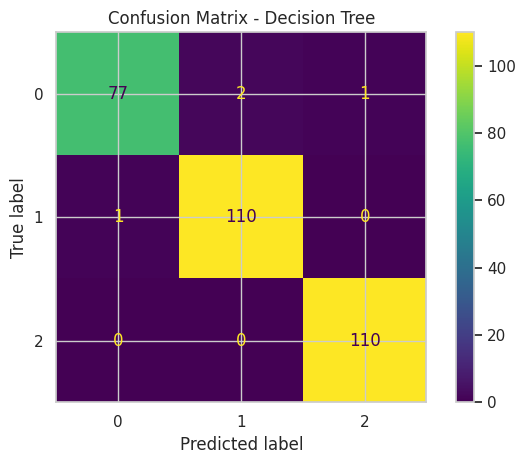

In [13]:
# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Decision Tree")
plt.show()

In [15]:
# ==============================
# SAVE MODEL
# ==============================

joblib.dump(dt_model, "decision_tree_model.h5")
files.download("decision_tree_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model klasifikasi pertama yang digunakan adalah Decision Tree.

Model ini dipilih sebagai baseline karena sederhana dan mudah diinterpretasikan.

Hasil evaluasi menunjukkan bahwa model mampu mempelajari pola dari data dengan performa sebagai berikut:
- Accuracy: 0.987
- Precision: 0.987
- Recall: 0.987
- F1 Score: 0.987

Note:
Accuracy : keseluruhan benar
Precision :	ketepatan prediksi
Recall :	kemampuan menangkap data
F1 Score :	balance precision & recall

# RANDOM FOREST

In [16]:
# ==============================
# RANDOM FOREST
# ==============================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Training
rf_model.fit(X_train, y_train)

# Prediksi
y_pred_rf = rf_model.predict(X_test)

## EVALUASI RANDOM FOREST

In [17]:
# ==============================
# EVALUASI RANDOM FOREST
# ==============================

print("Random Forest Performance:")

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_rf, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_rf, average='weighted'))

Random Forest Performance:
Accuracy : 0.9800664451827242
Precision: 0.9800664451827242
Recall   : 0.9800664451827242
F1 Score : 0.9800664451827242


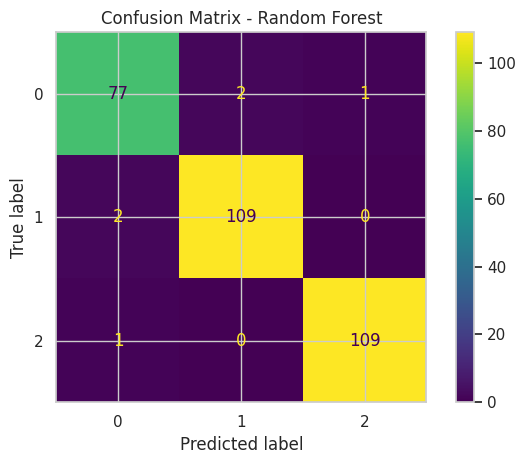

In [18]:
# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [19]:
# FEATURE IMPORTANCE
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

,0
TransactionAmount,0.258431
Amount_bin,0.221755
CustomerOccupation,0.219162
CustomerAge,0.175844
AccountBalance,0.092863
PreviousTransactionDate,0.008355
IP Address,0.008020
TransactionDuration,0.007355
Location,0.005955
Channel,0.002260


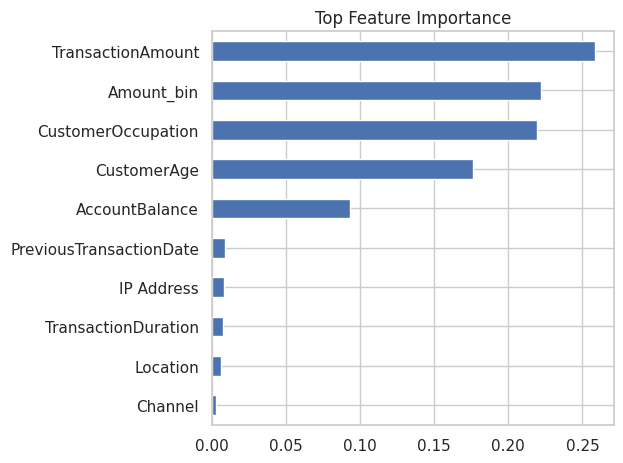

In [20]:
feature_importance.head(10).plot(kind='barh')
plt.title("Top Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [21]:
joblib.dump(rf_model, "explore_random_forest_classification.h5")
files.download("explore_random_forest_classification.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model kedua yang digunakan adalah Random Forest.

Random Forest merupakan metode ensemble yang menggabungkan beberapa Decision Tree untuk meningkatkan performa dan mengurangi overfitting.

Hasil evaluasi menunjukkan bahwa model Random Forest memiliki performa yang lebih stabil dibandingkan Decision Tree.

Selain itu, analisis feature importance menunjukkan bahwa beberapa fitur memiliki kontribusi yang lebih besar dalam menentukan hasil klasifikasi.

# RANDOM FOREST + HYPERPARAMETER TUNING (GridSearchCV)

In [22]:
# ==============================
# HYPERPARAMETER TUNING
# ==============================

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Ambil model terbaik
best_rf_model = grid_search.best_estimator_

# Prediksi
y_pred_tuned = best_rf_model.predict(X_test)

## EVALUASI MODEL TUNING

In [23]:
print("Tuned Random Forest Performance:")

print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_tuned, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_tuned, average='weighted'))

Tuned Random Forest Performance:
Accuracy : 0.9800664451827242
Precision: 0.9800664451827242
Recall   : 0.9800664451827242
F1 Score : 0.9800664451827242


In [24]:
joblib.dump(best_rf_model, "tuning_classification.h5")
files.download("tuning_classification.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Hyperparameter tuning tidak selalu menghasilkan performa terbaik pada data uji.

Hal ini dapat disebabkan oleh:
- Overfitting pada data training selama proses cross-validation
- Ukuran dataset yang terbatas
- Label yang digunakan berasal dari hasil clustering (unsupervised), sehingga mengandung noise

# PERBANDINGAN MODEL

In [25]:
results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_tuned)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_dt, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted'),
        f1_score(y_test, y_pred_tuned, average='weighted')
    ]
})

results

,Model,Accuracy,F1 Score
0,Decision Tree,0.986711,0.986657
1,Random Forest,0.980066,0.980066
2,Tuned Random Forest,0.980066,0.980066


Berdasarkan hasil evaluasi:

- Random Forest menunjukkan performa yang lebih stabil dibandingkan Decision Tree
- Hyperparameter tuning tidak selalu meningkatkan performa
- Model terbaik dipilih berdasarkan F1 Score karena mempertimbangkan keseimbangan precision dan recall